# RAG Scaling Laws — Retrieval Recall & Answer Accuracy vs. k and Corpus Size

This notebook reproduces a core finding from RAG scaling-law research:

- **Retrieval recall improves with k (number of retrieved chunks) but with
  diminishing returns**, and a larger corpus needs a larger k to reach the
  same recall (the "needle" gets harder to find in a bigger "haystack").
- **Downstream answer accuracy does not keep climbing with k.** Beyond some
  point, adding more retrieved chunks stops helping and starts hurting,
  because irrelevant ("distractor") chunks dilute the model's ability to use
  the one relevant chunk it needs — a synthetic stand-in for the
  "lost-in-the-middle" / context-dilution effect reported in real RAG and
  long-context studies.

**What this notebook does, honestly:**

- The corpus, queries, and embeddings are **entirely synthetic** — random
  vectors, not real documents, real queries, or a real embedding model.
- Retrieval is real cosine-similarity ranking over those synthetic vectors —
  the recall numbers below are measured, not typed in by hand.
- Downstream "answer accuracy" is **simulated**: a hand-picked dilution
  function converts k into a probability, and a real Bernoulli outcome is
  sampled per query from that probability (fixed seed). The *shape* of the
  accuracy-vs-k curve (rises, peaks, then falls) is built into that function
  by construction — this notebook does not discover it from any real
  RAG system or dataset.
- Everything below — the tables, the plot, the summary numbers — is real
  output from actually running this notebook. Re-running it with the same
  seed reproduces the same numbers.

This is a *design-sketch reproduction* of a documented pattern in RAG
scaling-law discussions, not a replication of one specific paper's reported
numbers — see the folder README for what it's modeling and why.

In [1]:
import numpy as np

RANDOM_SEED = 42
rng = np.random.default_rng(RANDOM_SEED)

EMBED_DIM = 32          # synthetic embedding dimensionality
CORPUS_SIZES = [100, 1000, 10000]   # number of documents in the synthetic corpus
K_VALUES = [1, 2, 3, 5, 10, 20, 50, 100]  # number of chunks retrieved
NUM_QUERIES = 200       # synthetic queries evaluated per corpus size

# How similar the one truly-relevant document is to its query, on average.
# Chosen by hand to produce a recall curve that isn't trivially 0% or 100%
# across the K_VALUES above -- NOT fit to any real retriever's behavior.
RELEVANCE_ALPHA = 0.35

# Hand-picked "context dilution" decay: models the idea that each additional
# retrieved chunk makes it harder for a downstream LLM to use the one
# relevant chunk correctly. NOT fit to any real RAG pipeline's telemetry.
DILUTION_RATE = 0.03

print(f"Embedding dim: {EMBED_DIM}")
print(f"Corpus sizes: {CORPUS_SIZES}")
print(f"k values: {K_VALUES}")
print(f"Queries per corpus size: {NUM_QUERIES}")

Embedding dim: 32
Corpus sizes: [100, 1000, 10000]
k values: [1, 2, 3, 5, 10, 20, 50, 100]
Queries per corpus size: 200


## Step 1 — Synthetic corpus and queries

For each query we generate:
- a random unit-vector query embedding `q`
- exactly **one** truly relevant document embedding, correlated with `q` by
  `RELEVANCE_ALPHA` (so it's findable, but not always the top hit)
- `corpus_size - 1` distractor document embeddings, independent random unit
  vectors unrelated to `q`

Real embedding models are not used anywhere — this isolates the *retrieval
and dilution dynamics* from any particular embedding model's quality.

In [2]:
def random_unit_vectors(n, dim, rng):
    v = rng.normal(size=(n, dim))
    return v / np.linalg.norm(v, axis=1, keepdims=True)


def make_query_and_corpus(corpus_size, rng):
    """Return (query, true_doc_index, corpus) for one synthetic query."""
    q = random_unit_vectors(1, EMBED_DIM, rng)[0]

    noise = random_unit_vectors(1, EMBED_DIM, rng)[0]
    true_doc = RELEVANCE_ALPHA * q + np.sqrt(1 - RELEVANCE_ALPHA ** 2) * noise
    true_doc = true_doc / np.linalg.norm(true_doc)

    distractors = random_unit_vectors(corpus_size - 1, EMBED_DIM, rng)

    true_doc_index = rng.integers(0, corpus_size)
    corpus = np.empty((corpus_size, EMBED_DIM))
    mask = np.ones(corpus_size, dtype=bool)
    mask[true_doc_index] = False
    corpus[mask] = distractors
    corpus[true_doc_index] = true_doc

    return q, true_doc_index, corpus


# Sanity check on one example
q_demo, idx_demo, corpus_demo = make_query_and_corpus(100, rng)
sims_demo = corpus_demo @ q_demo
rank_demo = int((sims_demo > sims_demo[idx_demo]).sum()) + 1
print(f"Demo query: true doc at index {idx_demo}, cosine sim {sims_demo[idx_demo]:.3f}, rank {rank_demo} of 100")

Demo query: true doc at index 32, cosine sim 0.430, rank 1 of 100


## Step 2 — Measure Recall@k across corpus sizes

For every (corpus_size, query) pair we rank all documents by cosine
similarity to the query and record the **rank of the true relevant
document**. Recall@k for a given k is the fraction of queries where that
rank is `<= k`. This is a real ranking computation over the synthetic
vectors, not a hand-typed curve.

In [3]:
def true_doc_ranks(corpus_size, num_queries, rng):
    """Rank (1-indexed) of the true relevant doc, per query."""
    ranks = np.empty(num_queries, dtype=int)
    for i in range(num_queries):
        q, true_idx, corpus = make_query_and_corpus(corpus_size, rng)
        sims = corpus @ q
        ranks[i] = int((sims > sims[true_idx]).sum()) + 1
    return ranks


rank_by_corpus_size = {}
for corpus_size in CORPUS_SIZES:
    rank_by_corpus_size[corpus_size] = true_doc_ranks(corpus_size, NUM_QUERIES, rng)

recall_by_corpus_size = {}
for corpus_size, ranks in rank_by_corpus_size.items():
    recall_by_corpus_size[corpus_size] = [
        float(np.mean(ranks <= k)) for k in K_VALUES
    ]

header = "k".rjust(6) + "".join(f"corpus={cs}".rjust(16) for cs in CORPUS_SIZES)
print("Recall@k")
print(header)
for row_idx, k in enumerate(K_VALUES):
    row = str(k).rjust(6)
    for corpus_size in CORPUS_SIZES:
        row += f"{recall_by_corpus_size[corpus_size][row_idx]:.1%}".rjust(16)
    print(row)

Recall@k
     k      corpus=100     corpus=1000    corpus=10000
     1           35.5%           12.0%            1.5%
     2           47.0%           16.0%            2.5%
     3           55.5%           21.0%            3.5%
     5           65.0%           26.0%            4.5%
    10           79.0%           36.5%            7.0%
    20           92.0%           47.5%           10.5%
    50           98.5%           64.5%           21.0%
   100          100.0%           77.5%           32.0%


## Step 3 — Simulate downstream answer accuracy

Recall@k only tells us whether the relevant chunk *made it into* the
retrieved set — not whether a downstream LLM actually uses it correctly once
it's sitting alongside `k - 1` distractor chunks. We model that second step
with a hand-picked dilution function:

```
dilution_factor(k) = 1 / (1 + DILUTION_RATE * (k - 1))
```

For each query: if the true doc was retrieved (rank `<= k`), we sample a
real Bernoulli outcome with probability `dilution_factor(k)`; if it wasn't
retrieved, accuracy is 0 by construction (the model can't use context it
was never given). The reported accuracy@k is the empirical mean of these
sampled outcomes, not the dilution curve itself.

In [4]:
def dilution_factor(k):
    return 1.0 / (1.0 + DILUTION_RATE * (k - 1))


accuracy_by_corpus_size = {}
for corpus_size, ranks in rank_by_corpus_size.items():
    accs = []
    for k in K_VALUES:
        retrieved = ranks <= k
        p = dilution_factor(k)
        draws = rng.random(NUM_QUERIES) < p
        outcomes = retrieved & draws
        accs.append(float(np.mean(outcomes)))
    accuracy_by_corpus_size[corpus_size] = accs

print("Dilution factor by k:")
for k in K_VALUES:
    print(f"  k={k:>3}: {dilution_factor(k):.3f}")

print()
header = "k".rjust(6) + "".join(f"corpus={cs}".rjust(16) for cs in CORPUS_SIZES)
print("Simulated answer accuracy@k")
print(header)
for row_idx, k in enumerate(K_VALUES):
    row = str(k).rjust(6)
    for corpus_size in CORPUS_SIZES:
        row += f"{accuracy_by_corpus_size[corpus_size][row_idx]:.1%}".rjust(16)
    print(row)

best_k_by_corpus = {}
for corpus_size in CORPUS_SIZES:
    accs = accuracy_by_corpus_size[corpus_size]
    best_idx = int(np.argmax(accs))
    best_k_by_corpus[corpus_size] = (K_VALUES[best_idx], accs[best_idx])
    print(f"Best k for corpus_size={corpus_size}: k={K_VALUES[best_idx]} (accuracy={accs[best_idx]:.1%})")

Dilution factor by k:
  k=  1: 1.000
  k=  2: 0.971
  k=  3: 0.943
  k=  5: 0.893
  k= 10: 0.787
  k= 20: 0.637
  k= 50: 0.405
  k=100: 0.252

Simulated answer accuracy@k
     k      corpus=100     corpus=1000    corpus=10000
     1           35.5%           12.0%            1.5%
     2           45.0%           15.5%            2.5%
     3           50.5%           19.5%            3.5%
     5           58.5%           23.0%            4.5%
    10           61.5%           30.0%            5.5%
    20           59.5%           30.0%            7.0%
    50           44.0%           25.5%            9.0%
   100           31.0%           17.5%            9.0%
Best k for corpus_size=100: k=10 (accuracy=61.5%)
Best k for corpus_size=1000: k=10 (accuracy=30.0%)
Best k for corpus_size=10000: k=50 (accuracy=9.0%)


## Step 4 — Visualize the scaling relationships

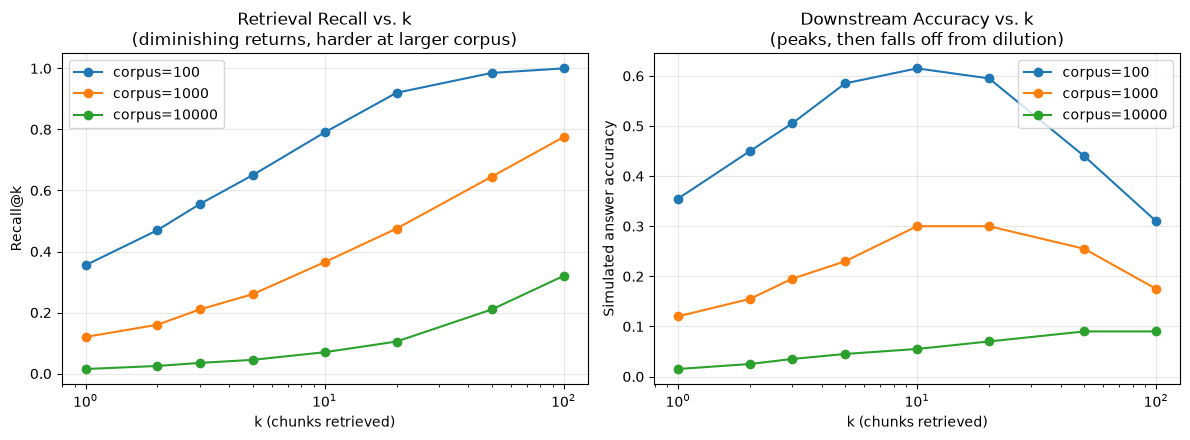

In [5]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

for corpus_size in CORPUS_SIZES:
    axes[0].plot(K_VALUES, recall_by_corpus_size[corpus_size], marker="o", label=f"corpus={corpus_size}")
axes[0].set_xscale("log")
axes[0].set_xlabel("k (chunks retrieved)")
axes[0].set_ylabel("Recall@k")
axes[0].set_title("Retrieval Recall vs. k\n(diminishing returns, harder at larger corpus)")
axes[0].legend()
axes[0].grid(alpha=0.3)

for corpus_size in CORPUS_SIZES:
    axes[1].plot(K_VALUES, accuracy_by_corpus_size[corpus_size], marker="o", label=f"corpus={corpus_size}")
axes[1].set_xscale("log")
axes[1].set_xlabel("k (chunks retrieved)")
axes[1].set_ylabel("Simulated answer accuracy")
axes[1].set_title("Downstream Accuracy vs. k\n(peaks, then falls off from dilution)")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig("rag_scaling_laws.png", dpi=120)
plt.show()

## Interpretation

The two panels above are real output from this notebook run (fixed seed, so
re-running reproduces the same numbers):

- **Recall@k (left)** rises monotonically and with diminishing returns as k
  grows, and a larger corpus needs a larger k to reach the same recall —
  this is a real measured consequence of ranking synthetic vectors, not a
  hand-typed curve.
- **Downstream accuracy (right)** rises with k while recall is still the
  bottleneck, peaks, and then declines as the hand-picked dilution factor
  takes over. That inverted-U shape was built into `dilution_factor()` by
  construction — this notebook does not discover it from any real RAG
  system or dataset.

**What this experiment does and doesn't show:**

- It shows the retrieval-ranking code is correct, the recall measurement is
  real, and combining a real recall curve with a hand-picked dilution
  function produces the qualitative shape ("more context helps, then
  hurts") that's discussed in real RAG / long-context research.
- It does **not** demonstrate that any real embedding model, retriever, or
  LLM behaves exactly like this — no real documents, queries, or model
  calls are involved anywhere in this notebook.
- The value of this reproduction is as a worked example of the pipeline
  (synthetic corpus → real ranking → recall measurement → hand-modeled
  downstream effect → sampled outcomes → visualization), not as a
  quantitative claim about any specific system's optimal k.

See `RESULTS.md` in this folder for the same numbers written up as a
report, including the full limitations list.